In [1]:
import polars as pl
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
data_results = pl.read_csv('bench_results.csv')

In [3]:
median_data = data_results.group_by('case', maintain_order=True).median()

In [4]:
median_data.head()

case,clock,ms
str,f64,f64
"""double_intrin_avx2""",4.05876097e8,150.995189
"""float_intrin_avx2""",2.07896588e8,77.342195
"""double_intrin_avx512""",2.13680792e8,79.494451
"""float_intrin_avx512""",1.05686145e8,39.31883
"""double_simple""",1.3175e9,490.157887


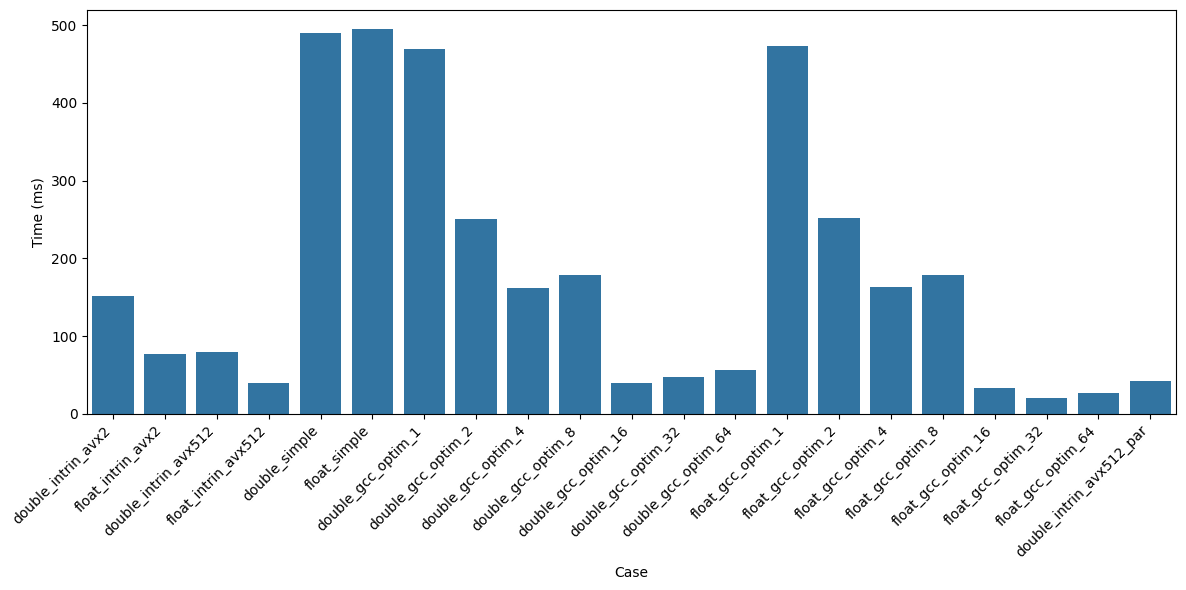

In [5]:
plt.figure(figsize=(12, 6))
sns.barplot(data=median_data, x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()

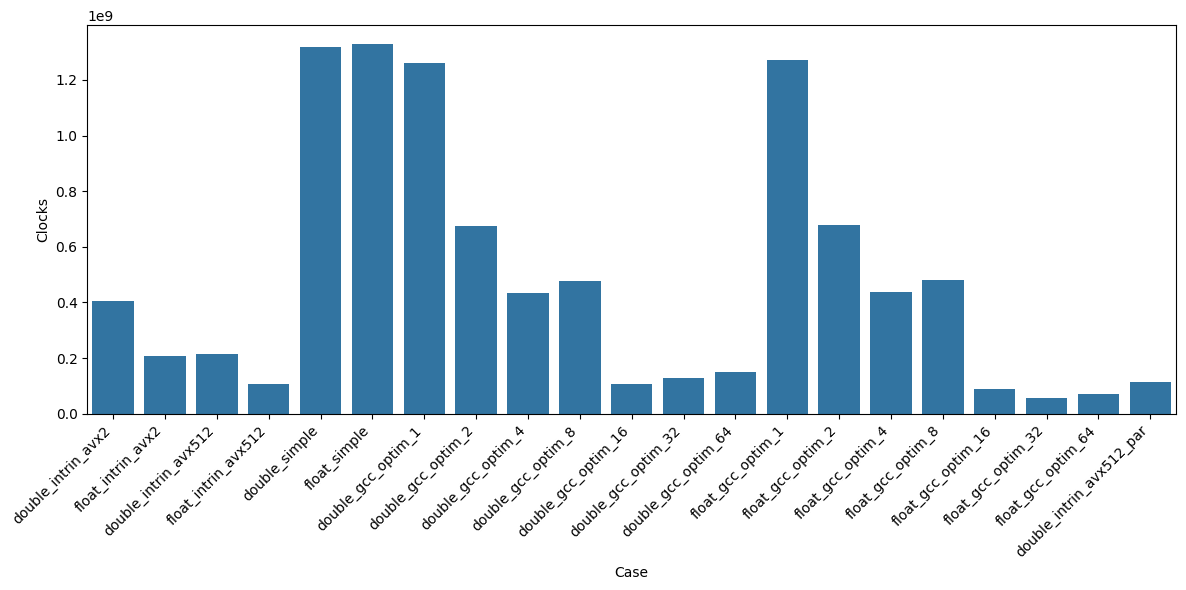

In [6]:
plt.figure(figsize=(12, 6))
sns.barplot(data=median_data, x='case', y='clock')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Clocks')

plt.tight_layout()
plt.show()

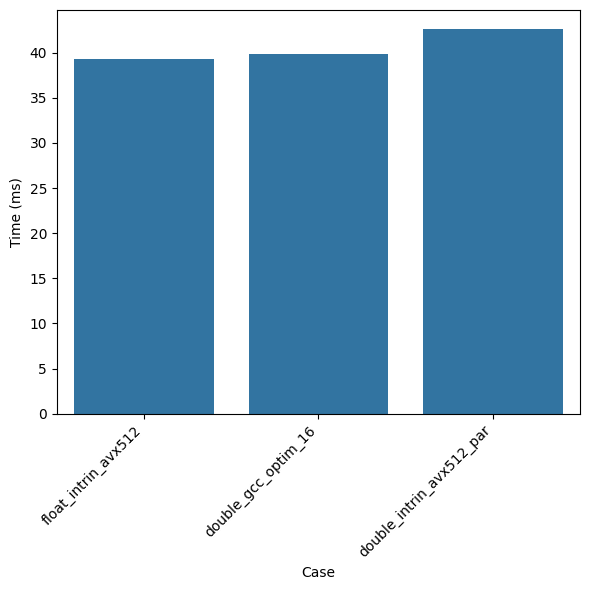

In [8]:
plt.figure(figsize=(6, 6))
sns.barplot(data=median_data.filter(pl.col('case').is_in(['float_intrin_avx512', 'double_gcc_optim_16', 'double_intrin_avx512_par'])), x='case', y='ms')

plt.xticks(rotation=45, ha='right')

plt.xlabel('Case')
plt.ylabel('Time (ms)')

plt.tight_layout()
plt.show()